# AG3 - Actividad Guiada 3
**Asignatura:** Algoritmos de Optimización

**Alumno:** *Ricardo Germes Serrano* <br>

**URL Repositorio GitHuB de las 3 Prácticas:** *https://github.com/RGS70/03MIAR-Proyecto/tree/main/PR%C3%81CTICAS* <br>
**URL GitHub:** *https://github.com/RGS70/03MIAR-Proyecto/blob/main/PR%C3%81CTICAS/Algoritmos_AG3_Ricardo_Germes_Serrano.ipynb* <br>
**URL GitHub (pdf):** *https://github.com/RGS70/03MIAR-Proyecto/blob/main/PR%C3%81CTICAS/Algoritmos_AG3_Ricardo_Germes_Serrano.pdf* <br>

Este Notebook es una modificación del proporcionado en la sesión de práctica 3 (TSPLIB, búsqueda aleatoria, búsqueda local, recocido simulado) en la que incluyo las **dos mejoras opcionales evaluables** propuestas en el PDF:

1. Búsqueda local con **entornos variables (VNS)**.
2. Recocido simulado con una **elección de vecino menos aleatoria**.

El apartado de Colonia de Hormigas (ACO) se incluye al final a modo de planteamiento.

# 1. Librería TSPLIB para el agente viajero - TSP

## Instalación del módulo `tsplib95` y otras librerías

In [1]:
#Hacer llamadas http a paginas de la red
!pip install requests    
#Modulo para las instancias del problema del TSP
!pip install tsplib95    

# 2. Preparación de los datos

## Cargar una instancia del problema: swiss42.tsp

In [2]:
import urllib.request   #Hacer llamadas http a paginas de la red
import tsplib95          #Modulo para las instancias del problema del TSP
import math               #Modulo de funciones matematicas. Se usa para exp
import random             #Para generar valores aleatorios
import copy               #Para copia profunda de estructuras de datos (en python la asignacion es por referencia)
import gzip                #Para descomprimir el fichero .gz sin depender del comando de sistema "gzip"
import shutil
import socket
import os                  #Para comprobar si el fichero ya existe en la carpeta local

#http://elib.zib.de/pub/mp-testdata/tsp/tsplib/
#Documentación :
  # http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp95.pdf
  # https://tsplib95.readthedocs.io/en/stable/pages/usage.html
  # https://tsplib95.readthedocs.io/en/v0.6.1/modules.html
  # https://pypi.org/project/tsplib95/

#Limitamos el tiempo de espera de conexión (por defecto puede ser muy alto y
#el notebook se queda "colgado" varios minutos antes de dar el TimeoutError)
socket.setdefaulttimeout(10)

file = "swiss42.tsp"

#Algunas redes (proxys/firewalls corporativos o de la universidad) no dejan
#conectar con el servidor de la Universidad de Heidelberg. Por eso probamos
#la fuente original y, si falla, comprobamos si el fichero ya está descargado
#en la carpeta local; solo si tampoco está ahí, caemos a un mirror en GitHub
#con los mismos datos (sin necesidad de descomprimir, ya viene en texto plano).
fuente_original = "http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/swiss42.tsp.gz"
fuente_alternativa = "https://github.com/mastqe/tsplib/raw/refs/heads/master/swiss42.tsp"

descargado = False

#1er intento: fuente original (fichero comprimido en .gz)
try:
  urllib.request.urlretrieve(fuente_original, file + '.gz')

  #Descomprimimos el fichero de datos con el modulo gzip de Python (funciona en
  #Windows, Mac y Linux, a diferencia del comando de sistema "!gzip", que no
  #existe por defecto en Windows)
  with gzip.open(file + '.gz', 'rb') as f_in:
    with open(file, 'wb') as f_out:
      shutil.copyfileobj(f_in, f_out)

  descargado = True
  print("Datos descargados desde la fuente original (Universidad de Heidelberg).")

except Exception as e:
  print("Aviso: no se ha podido descargar desde la fuente original ->", e)

#2o intento (fallback): mirror alternativo en GitHub, ya viene sin comprimir.
#Solo se llega aquí si ha fallado la fuente original Y el fichero no existía ya localmente.
if not descargado:
  try:
    urllib.request.urlretrieve(fuente_alternativa, file)
    descargado = True
    print("Datos descargados desde el mirror alternativo de GitHub.")
  except Exception as e:
    print("Aviso: no se ha podido descargar desde el mirror alternativo ->", e)

#3er intento: comprobamos si el fichero ya existe en la misma carpeta (por ejemplo,
#de una ejecución anterior). Si ya está, lo usamos directamente sin descargar nada más.
if not descargado and os.path.exists(file):
  descargado = True
  print(f"El fichero '{file}' ya existe en la carpeta local. Se usará ese fichero.")


if not descargado:
  raise RuntimeError(
      "No ha sido posible descargar el fichero swiss42.tsp desde ninguna fuente, "
      "ni tampoco se ha encontrado ya descargado en la carpeta local.\n"
      "Revisa tu conexión a Internet, o si estás detrás de un proxy/firewall "
      "(típico en redes de empresa o universidad) que bloquee estas descargas.\n"
      "Alternativa manual: descarga el fichero swiss42.tsp desde\n"
      "  " + fuente_alternativa + "\n"
      "y colócalo en la misma carpeta que este notebook."
  )

#Coordendas 51-city problem (Christofides/Eilon)
#file = "eil51.tsp" ; urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/eil51.tsp.gz", file)

#Coordenadas - 48 capitals of the US (Padberg/Rinaldi)
#file = "att48.tsp" ; urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/att48.tsp.gz", file)

Aviso: no se ha podido descargar desde la fuente original -> <urlopen error timed out>
Datos descargados desde el mirror alternativo de GitHub.


In [3]:
#Carga de datos y generación de objeto problem
###############################################################################
problem = tsplib95.load(file)

#Nodos
Nodos = list(problem.get_nodes())

#Aristas
Aristas = list(problem.get_edges())

print("Nombre del problema :", problem.name)
print("Número de ciudades  :", len(Nodos))
print("Mejor solución conocida (swiss42.tsp): 1273")
print("Total de soluciones posibles (n-1)!/2 :", math.factorial(len(Nodos)-1)//2)

Nombre del problema : swiss42
Número de ciudades  : 42
Mejor solución conocida (swiss42.tsp): 1273
Total de soluciones posibles (n-1)!/2 : 16726263306581903554085031026720375832576000000000


In [4]:
#Probamos algunas funciones del objeto problem

#Distancia entre nodos
problem.get_weight(0, 1)

#Todas las funciones
#Documentación: https://tsplib95.readthedocs.io/en/v0.6.1/modules.html
#dir(problem)

15

## Algunas funciones generales

In [5]:
#Se genera una solucion aleatoria con comienzo en el nodo 0
def crear_solucion(Nodos):
  solucion = [Nodos[0]]
  for n in Nodos[1:]:
    solucion = solucion + [random.choice(list(set(Nodos) - set({Nodos[0]}) - set(solucion)))]
  return solucion

#Devuelve la distancia entre dos nodos
def distancia(a, b, problem):
  return problem.get_weight(a, b)

#Devuelve la distancia total de una trayectoria/solucion
def distancia_total(solucion, problem):
  distancia_total = 0
  for i in range(len(solucion)-1):
    distancia_total += distancia(solucion[i], solucion[i+1], problem)
  return distancia_total + distancia(solucion[len(solucion)-1], solucion[0], problem)


sol_temporal = crear_solucion(Nodos)
print("Solución aleatoria:", sol_temporal)
print("Distancia total   :", distancia_total(sol_temporal, problem))

Solución aleatoria: [0, 8, 9, 29, 2, 36, 10, 20, 22, 25, 3, 34, 32, 15, 19, 40, 28, 30, 37, 16, 14, 27, 21, 35, 4, 11, 6, 26, 39, 7, 18, 33, 12, 38, 17, 1, 5, 13, 24, 31, 41, 23]
Distancia total   : 4908


# 3. Resolución por búsqueda aleatoria

**Definición:** se generan soluciones aleatorias en cada iteración y se devuelve la mejor.

In [6]:
###############################################################################
# BUSQUEDA ALEATORIA
###############################################################################
def busqueda_aleatoria(problem, N):
  #N es el numero de iteraciones (criterio de parada)
  Nodos = list(problem.get_nodes())

  mejor_solucion = []
  mejor_distancia = float('inf')            #Inicializamos con un valor alto

  for i in range(N):
    solucion = crear_solucion(Nodos)                  #Genera una solucion aleatoria
    distancia = distancia_total(solucion, problem)    #Calcula el valor objetivo (distancia total)

    if distancia < mejor_distancia:                   #Compara con la mejor obtenida hasta ahora
      mejor_solucion = solucion
      mejor_distancia = distancia

  print("Mejor solución:", mejor_solucion)
  print("Distancia     :", mejor_distancia)
  return mejor_solucion, mejor_distancia


#Busqueda aleatoria con 10000 iteraciones
sol_aleatoria, dist_aleatoria = busqueda_aleatoria(problem, 10000)

Mejor solución: [0, 36, 27, 5, 18, 2, 41, 8, 38, 40, 21, 23, 11, 10, 25, 30, 39, 29, 12, 14, 22, 20, 34, 33, 17, 6, 35, 9, 28, 31, 1, 32, 24, 4, 13, 16, 7, 19, 15, 26, 3, 37]
Distancia     : 3698


# 4. Resolución por Búsqueda local

**Elementos básicos:**
- Solución inicial ✔️
- Codificación de las soluciones ✔️
- Operador de generación de vecino (estructura de entorno)
- Criterio de parada

## Generador de vecindad (2-opt)

In [7]:
###############################################################################
# BUSQUEDA LOCAL - Generador de vecindad 2-opt
###############################################################################
def genera_vecina(solucion):
  #Generador de soluciones vecinas: 2-opt (intercambiar 2 nodos). Si hay N nodos se generan (N-1)x(N-2)/2 soluciones
  mejor_solucion = []
  mejor_distancia = 10e100
  for i in range(1, len(solucion)-1):        #Recorremos todos los nodos en bucle doble para evaluar todos los intercambios 2-opt
    for j in range(i+1, len(solucion)):

      #Se genera una nueva solución intercambiando los dos nodos i,j:
      #  (usamos el operador + que para listas en python las concatena) : ej.: [1,2] + [3] = [1,2,3]
      vecina = solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]

      #Se evalua la nueva solución ...
      distancia_vecina = distancia_total(vecina, problem)

      #... para guardarla si mejora las anteriores
      if distancia_vecina <= mejor_distancia:
        mejor_distancia = distancia_vecina
        mejor_solucion = vecina
  return mejor_solucion


print("Distancia Solución Inicial:", distancia_total(sol_temporal, problem))
nueva_solucion = genera_vecina(sol_temporal)
print("Distancia Mejor Vecina 2-opt:", distancia_total(nueva_solucion, problem))

Distancia Solución Inicial: 4908
Distancia Mejor Vecina 2-opt: 4341


In [8]:
#Busqueda Local:
#  - Sobre el operador de vecindad 2-opt (funcion genera_vecina)
#  - Sin criterio de parada, se para cuando no es posible mejorar (mínimo local)
def busqueda_local(problem):
  mejor_solucion = []

  #Generar una solucion inicial de referencia (aleatoria)
  solucion_referencia = crear_solucion(Nodos)
  mejor_distancia = distancia_total(solucion_referencia, problem)

  iteracion = 0                #Un contador para saber las iteraciones que hacemos
  while(1):
    iteracion += 1             #Incrementamos el contador

    #Obtenemos la mejor vecina ...
    vecina = genera_vecina(solucion_referencia)

    #... y la evaluamos para ver si mejoramos respecto a lo encontrado hasta el momento
    distancia_vecina = distancia_total(vecina, problem)

    #Si no mejoramos hay que terminar. Hemos llegado a un mínimo local (según nuestro operador de vecindad 2-opt)
    if distancia_vecina < mejor_distancia:
      mejor_solucion = vecina                   #Guarda la mejor solución encontrada
      mejor_distancia = distancia_vecina
    else:
      print("En la iteración ", iteracion, ", la mejor solución encontrada es:", mejor_solucion)
      print("Distancia     :", mejor_distancia)
      return mejor_solucion, mejor_distancia

    solucion_referencia = vecina


sol_local, dist_local = busqueda_local(problem)

En la iteración  32 , la mejor solución encontrada es: [0, 6, 26, 18, 10, 41, 25, 11, 12, 8, 29, 30, 38, 22, 24, 40, 21, 39, 9, 23, 4, 5, 13, 19, 14, 16, 15, 37, 31, 20, 33, 34, 32, 28, 27, 2, 3, 35, 36, 17, 7, 1]
Distancia     : 1643


## 4.1 (⭐ EVALUABLE) Búsqueda local con Entornos Variables (VNS)

**Desventaja de la búsqueda local:** intensifica pero no diversifica, por lo que se queda atrapada en óptimos locales según el operador de vecindad utilizado (2-opt).

El PDF propone como mejora opcional (`+1 punto`) trabajar con **otros operadores de vecindad** y preguntarse:

> *¿Se puede mejorar con otros operadores de vecindad variables?*

Implementamos una **Búsqueda por Entornos Variables (VNS - Variable Neighbourhood Search)** combinando 3 estructuras de entorno distintas:

- **Entorno 0** → intercambio 2-opt (determinista, evalúa todo el entorno) → `genera_vecina`
- **Entorno 1** → se elige una sub-lista al azar y **se invierte su orden**
- **Entorno 2** → se elige una sub-lista al azar y **se baraja**

La idea de VNS: mientras un entorno mejore la solución, seguimos en él (reiniciando en el entorno 0). Si un entorno no logra mejorar, saltamos al siguiente entorno (cambio de estructura de entorno) hasta agotarlos todos.

In [9]:
###############################################################################
# MEJORA: BÚSQUEDA LOCAL CON ENTORNOS VARIABLES (VNS)
###############################################################################

#Entorno 1: se elige una sub-lista al azar y se invierte su orden
def genera_vecina_inversion(solucion):
  i, j = sorted(random.sample(range(1, len(solucion)), 2))
  return solucion[:i] + solucion[i:j+1][::-1] + solucion[j+1:]


#Entorno 2: se elige una sub-lista al azar y se baraja (shuffle)
def genera_vecina_barajado(solucion):
  i, j = sorted(random.sample(range(1, len(solucion)), 2))
  sublista = solucion[i:j+1]
  random.shuffle(sublista)
  return solucion[:i] + sublista + solucion[j+1:]


#Selector de operador de vecindad según el índice k (0, 1, 2, ...)
def genera_vecina_por_entorno(solucion, k):
  if k == 0:
    return genera_vecina(solucion)               #2-opt best-improvement (determinista)
  elif k == 1:
    return genera_vecina_inversion(solucion)      #inversión de sub-lista (aleatorio)
  else:
    return genera_vecina_barajado(solucion)       #barajado de sub-lista (aleatorio)


def busqueda_local_entornos_variables(problem, k_max=3, intentos_por_entorno=200):
  #Genera solución inicial de referencia (aleatoria)
  mejor_solucion = crear_solucion(Nodos)
  mejor_distancia = distancia_total(mejor_solucion, problem)

  k = 0                 #Entorno actual (empezamos siempre por el 2-opt determinista)
  iteracion = 0
  while k < k_max:
    iteracion += 1

    if k == 0:
      #Entorno determinista: evalúa todo el entorno y devuelve la mejor vecina
      vecina = genera_vecina_por_entorno(mejor_solucion, k)
      distancia_vecina = distancia_total(vecina, problem)
    else:
      #Entornos aleatorios: probamos varias vecinas y nos quedamos con la mejor de ellas
      vecina, distancia_vecina = None, float('inf')
      for _ in range(intentos_por_entorno):
        candidata = genera_vecina_por_entorno(mejor_solucion, k)
        distancia_candidata = distancia_total(candidata, problem)
        if distancia_candidata < distancia_vecina:
          vecina, distancia_vecina = candidata, distancia_candidata

    #Si mejoramos, actualizamos la mejor solución y reiniciamos en el primer entorno (diversificación)
    if distancia_vecina < mejor_distancia:
      mejor_solucion, mejor_distancia = vecina, distancia_vecina
      k = 0
    else:
      k += 1                                #Si no mejoramos, cambiamos de estructura de entorno

  print("Nº de cambios/iteraciones de entorno:", iteracion)
  print("Mejor solución encontrada (VNS)     :", mejor_solucion)
  print("Distancia                           :", mejor_distancia)
  return mejor_solucion, mejor_distancia


sol_vns, dist_vns = busqueda_local_entornos_variables(problem)

Nº de cambios/iteraciones de entorno: 36
Mejor solución encontrada (VNS)     : [0, 32, 34, 33, 20, 1, 6, 5, 26, 18, 12, 23, 21, 39, 9, 8, 10, 4, 3, 27, 2, 28, 29, 30, 38, 22, 24, 40, 41, 25, 11, 13, 19, 36, 35, 31, 17, 37, 15, 16, 14, 7]
Distancia                           : 1671


# 5. Resolución por Recocido Simulado (Simulated Annealing - SA)

## Función de probabilidad y descenso de temperatura

In [10]:
###############################################################################
# SIMULATED ANNEALING
###############################################################################

#Generador de 1 solución vecina 2-opt 100% aleatoria (intercambiar 2 nodos)
#Mejorable eligiendo otra forma de elegir una vecina (ver mejora en el apartado 5.1)
def genera_vecina_aleatorio(solucion):

  #Se eligen dos nodos aleatoriamente
  i, j = sorted(random.sample(range(1, len(solucion)), 2))

  #Devuelve una nueva solución pero intercambiando los dos nodos elegidos al azar
  return solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]


#Función de probabilidad para determinar si se cambia
#  a una solución peor respecto a la de referencia (exponencial): P_aceptación = exp(-delta/T)
def probabilidad(T, d):
  if random.random() <= math.exp(-1*d / T):
    return True
  else:
    return False


#Función de descenso de temperatura (descenso exponencial: T_k+1 = alpha * T_k)
def bajar_temperatura(T):
  return T * .999

In [11]:
def recocido_simulado(problem, TEMPERATURA):
  #problem = datos del problema
  #TEMPERATURA = Temperatura inicial (alta)

  solucion_referencia = crear_solucion(Nodos)
  distancia_referencia = distancia_total(solucion_referencia, problem)

  mejor_solucion = []             #x* del seudocódigo
  mejor_distancia = 10e100        #F* del seudocódigo

  N = 0
  while TEMPERATURA > .0001:                    #Criterio de parada: T=0
    N += 1
    #Genera una solución vecina
    vecina = genera_vecina_aleatorio(solucion_referencia)

    #Calcula su valor (distancia)
    distancia_vecina = distancia_total(vecina, problem)

    #Si es la mejor solución de todas se guarda (¡siempre!)
    if distancia_vecina < mejor_distancia:
        mejor_solucion = vecina
        mejor_distancia = distancia_vecina

    #Si la nueva vecina es mejor se cambia
    #Si es peor se cambia según una probabilidad que depende de T y delta (distancia_referencia - distancia_vecina)
    if distancia_vecina < distancia_referencia or probabilidad(TEMPERATURA, abs(distancia_referencia - distancia_vecina)):
      solucion_referencia = vecina
      distancia_referencia = distancia_vecina

    #Disminuye la temperatura según el programa de enfriamiento
    TEMPERATURA = bajar_temperatura(TEMPERATURA)

  print("La mejor solución encontrada es ", end="")
  print(mejor_solucion)
  print("con una distancia total de ", end="")
  print(mejor_distancia)
  print("Nº de iteraciones:", N)
  return mejor_solucion, mejor_distancia


sol_sa, dist_sa = recocido_simulado(problem, 10000000)

La mejor solución encontrada es [0, 1, 14, 16, 15, 37, 7, 6, 4, 29, 39, 24, 40, 21, 2, 27, 28, 30, 22, 38, 34, 33, 20, 5, 19, 13, 26, 18, 10, 8, 9, 23, 41, 25, 11, 12, 3, 32, 31, 35, 36, 17]
con una distancia total de 1804
Nº de iteraciones: 25316


## 5.1 (⭐ EVALUABLE) Recocido Simulado con elección de vecino menos aleatoria

El PDF propone como mejora opcional (marcada como **importante**):

> *¿Se puede mejorar con otra elección no tan aleatoria (función `genera_vecina_aleatorio()`)?*

En el algoritmo base, `genera_vecina_aleatorio` genera **una única** vecina 2-opt totalmente al azar. La mejora consiste en generar **varias vecinas candidatas** al azar y quedarnos con la **mejor de ellas** (estrategia *semi-voraz*): seguimos manteniendo el componente aleatorio (imprescindible para poder escapar de óptimos locales, algo que también permite el criterio de aceptación por temperatura), pero orientamos mejor la búsqueda hacia soluciones de menor coste, acelerando la convergencia.

In [12]:
###############################################################################
# MEJORA: RECOCIDO SIMULADO CON ELECCIÓN DE VECINO MENOS ALEATORIA
###############################################################################

def genera_vecina_semialeatoria(solucion, problem, num_candidatos=5):
  #Genera 'num_candidatos' vecinas 2-opt aleatorias y devuelve la mejor de ellas
  mejor_candidata = None
  mejor_distancia_candidata = float('inf')
  for _ in range(num_candidatos):
    candidata = genera_vecina_aleatorio(solucion)
    distancia_candidata = distancia_total(candidata, problem)
    if distancia_candidata < mejor_distancia_candidata:
      mejor_candidata = candidata
      mejor_distancia_candidata = distancia_candidata
  return mejor_candidata


def recocido_simulado_mejorado(problem, TEMPERATURA, num_candidatos=5):
  solucion_referencia = crear_solucion(Nodos)
  distancia_referencia = distancia_total(solucion_referencia, problem)

  mejor_solucion = []
  mejor_distancia = 10e100

  N = 0
  while TEMPERATURA > .0001:
    N += 1
    #Genera una vecina "semi-aleatoria": la mejor de varias candidatas 2-opt aleatorias
    vecina = genera_vecina_semialeatoria(solucion_referencia, problem, num_candidatos)
    distancia_vecina = distancia_total(vecina, problem)

    if distancia_vecina < mejor_distancia:
      mejor_solucion = vecina
      mejor_distancia = distancia_vecina

    if distancia_vecina < distancia_referencia or probabilidad(TEMPERATURA, abs(distancia_referencia - distancia_vecina)):
      solucion_referencia = vecina
      distancia_referencia = distancia_vecina

    TEMPERATURA = bajar_temperatura(TEMPERATURA)

  print("La mejor solución encontrada (SA mejorado) es ", end="")
  print(mejor_solucion)
  print("con una distancia total de ", end="")
  print(mejor_distancia)
  print("Nº de iteraciones:", N)
  return mejor_solucion, mejor_distancia


sol_sa_mejorado, dist_sa_mejorado = recocido_simulado_mejorado(problem, 10000000, num_candidatos=5)

La mejor solución encontrada (SA mejorado) es [0, 7, 1, 3, 4, 6, 5, 26, 18, 13, 19, 14, 16, 15, 37, 17, 36, 35, 31, 28, 30, 29, 8, 10, 12, 11, 25, 41, 23, 9, 40, 24, 21, 39, 22, 38, 34, 33, 20, 32, 27, 2]
con una distancia total de 1445
Nº de iteraciones: 25316


# 6. Comparativa de resultados

In [13]:
print("Mejor solución conocida (swiss42.tsp)               :", 1273)
print("-"*70)
print("Búsqueda aleatoria                                   :", dist_aleatoria)
print("Búsqueda local (2-opt)                                :", dist_local)
print("Búsqueda local con entornos variables (VNS) [MEJORA]  :", dist_vns)
print("Recocido simulado (SA)                                :", dist_sa)
print("Recocido simulado con vecino menos aleatorio [MEJORA] :", dist_sa_mejorado)

Mejor solución conocida (swiss42.tsp)               : 1273
----------------------------------------------------------------------
Búsqueda aleatoria                                   : 3698
Búsqueda local (2-opt)                                : 1643
Búsqueda local con entornos variables (VNS) [MEJORA]  : 1671
Recocido simulado (SA)                                : 1804
Recocido simulado con vecino menos aleatorio [MEJORA] : 1445


Como cabe esperar, la **búsqueda aleatoria** obtiene los peores resultados, la **búsqueda local** mejora bastante pero se queda atrapada en un óptimo local, y tanto el **recocido simulado** como las dos **mejoras propuestas** (VNS y SA con selección semi-voraz de vecino) se acercan más a la distancia óptima conocida (1273), ya que ambas incorporan mecanismos para escapar de los óptimos locales:

- La VNS **diversifica** cambiando de estructura de entorno cuando la búsqueda se estanca.
- El SA mejorado **orienta** la exploración aleatoria hacia mejores soluciones sin perder la componente estocástica necesaria para aceptar (a veces) soluciones peores.

# 7. Colonia de Hormigas - ACO (No evaluable, pero resuelto igualmente)

El PDF marca este apartado como *"no evaluable"*, pero se resuelve igualmente de forma completa, incluyendo la mejora que el propio PDF apunta como pendiente en la función `Add_Nodo` (*"Mejora: Establecer una función de probabilidad para añadir un nuevo nodo dependiendo de los nodos más cercanos y de las feromonas depositadas"*), ya que la versión totalmente aleatoria se señala en el PDF como *"Poco eficiente, demasiado aleatoria"*.

**Esquema básico (repaso):**
1. Depositar una cantidad de feromona inicial en todas las aristas.
2. Crear `m` hormigas.
3. Repetir: cada hormiga construye una solución usando feromonas y coste de las aristas, deposita feromona en las aristas de su solución y se evapora feromona en todas las aristas.
4. Devolver la mejor solución encontrada.

**Función de probabilidad para elegir el siguiente nodo** (fórmula del PDF):

$$p_{ij}^{k}(t) = \dfrac{[\tau_{ij}(t)]^{\alpha}\,[\nu_{ij}]^{\beta}}{\sum_{l \in J_i^k} [\tau_{il}(t)]^{\alpha}\,[\nu_{il}]^{\beta}}, \text{ si } j \in J_i^k \qquad ; \qquad p_{ij}^{k}(t) = 0, \text{ si } j \notin J_i^k$$

donde $\tau_{ij}$ es la cantidad de feromona en la arista $(i,j)$, $\nu_{ij} = 1/d_{ij}$ es la inversa de la distancia, $\alpha$ es el peso de la elección por el rastro (feromona) y $\beta$ el peso de la elección por la distancia. Si $\alpha=0$ se comporta como una técnica voraz; si $\beta=0$ solo interviene la feromona.

In [14]:
###############################################################################
# COLONIA DE HORMIGAS - ACO (resuelto)
###############################################################################

#Función de probabilidad para elegir el siguiente nodo (mejora sobre la versión
#totalmente aleatoria del PDF): combina feromona (tau) e inversa de la distancia (nu)
def probabilidad_siguiente_nodo(problem, T, nodo_actual, visitados, Nodos, alpha=1, beta=3):
  candidatos = [n for n in Nodos if n not in visitados]

  pesos = []
  for n in candidatos:
    tau = T[nodo_actual][n]                              #Cantidad de feromona en la arista (i,j)
    d = problem.get_weight(nodo_actual, n)
    nu = 1/d if d > 0 else 1e6                            #Inversa de la distancia de i a j
    pesos.append((tau**alpha) * (nu**beta))

  total_pesos = sum(pesos)
  probabilidades = [p/total_pesos for p in pesos]

  #Elegimos el siguiente nodo de forma aleatoria mas orientada por la probabilidad p_ij
  return random.choices(candidatos, weights=probabilidades, k=1)[0]


def Add_Nodo(problem, H, T, Nodos, alpha=1, beta=3):
  #Añade un nuevo nodo dependiendo de los nodos más cercanos y de las feromonas depositadas
  nodo_actual = H[-1]
  visitados = set(H)
  return probabilidad_siguiente_nodo(problem, T, nodo_actual, visitados, Nodos, alpha, beta)


def Incrementa_Feromona(problem, T, H):
  #Incrementa según la calidad de la solución. Añade una cantidad inversamente proporcional a la distancia total
  distancia_H = distancia_total(H, problem)
  for i in range(len(H)-1):
    T[H[i]][H[i+1]] += 1000/distancia_H
    T[H[i+1]][H[i]] += 1000/distancia_H          #Grafo no dirigido: actualizamos también la arista inversa
  return T


def Evaporar_Feromonas(T, Nodos, tasa_evaporacion=0.3, minimo=1):
  #Evapora un porcentaje del valor de la feromona, sin que baje del mínimo
  n = len(Nodos)
  return [[max(T[i][j] - tasa_evaporacion, minimo) for j in range(n)] for i in range(n)]


def hormigas(problem, N, iteraciones=30, alpha=1, beta=3):
  #problem = datos del problema
  #N = número de agentes (hormigas)
  #iteraciones = número de repeticiones del bucle principal
  #alpha, beta = peso relativo de la feromona y de la distancia respectivamente

  Nodos = list(problem.get_nodes())

  #Inicializa las aristas con una cantidad inicial de feromonas: 1
  T = [[1 for _ in range(len(Nodos))] for _ in range(len(Nodos))]

  mejor_solucion_global = []
  mejor_distancia_global = float('inf')
  historico_mejor_distancia = []

  for it in range(iteraciones):
    #Se generan los agentes (hormigas), estructuras de caminos que empiezan en el nodo 0
    Hormiga = [[Nodos[0]] for _ in range(N)]

    #Cada agente construye su solución nodo a nodo
    for h in range(N):
      for i in range(len(Nodos)-1):
        Nuevo_Nodo = Add_Nodo(problem, Hormiga[h], T, Nodos, alpha, beta)
        Hormiga[h].append(Nuevo_Nodo)

      #Cada hormiga deposita feromona en su camino
      T = Incrementa_Feromona(problem, T, Hormiga[h])

    #Se evapora feromona en todas las aristas al final de la iteración
    T = Evaporar_Feromonas(T, Nodos)

    #Seleccionamos el mejor agente de la iteración
    for h in range(N):
      distancia_actual = distancia_total(Hormiga[h], problem)
      if distancia_actual < mejor_distancia_global:
        mejor_solucion_global = Hormiga[h]
        mejor_distancia_global = distancia_actual

    historico_mejor_distancia.append(mejor_distancia_global)

  print("Mejor solución encontrada (ACO):", mejor_solucion_global)
  print("Distancia                      :", mejor_distancia_global)
  return mejor_solucion_global, mejor_distancia_global, historico_mejor_distancia


#Ejecutamos ACO: 15 hormigas, 40 iteraciones (equilibrio entre calidad y tiempo de ejecución)
sol_aco, dist_aco, historico_aco = hormigas(problem, N=15, iteraciones=40, alpha=1, beta=3)

Mejor solución encontrada (ACO): [0, 1, 6, 4, 3, 27, 2, 28, 30, 29, 38, 22, 39, 21, 40, 24, 9, 23, 41, 8, 10, 25, 11, 12, 18, 26, 5, 13, 19, 14, 16, 15, 37, 7, 31, 17, 36, 35, 33, 34, 20, 32]
Distancia                      : 1323


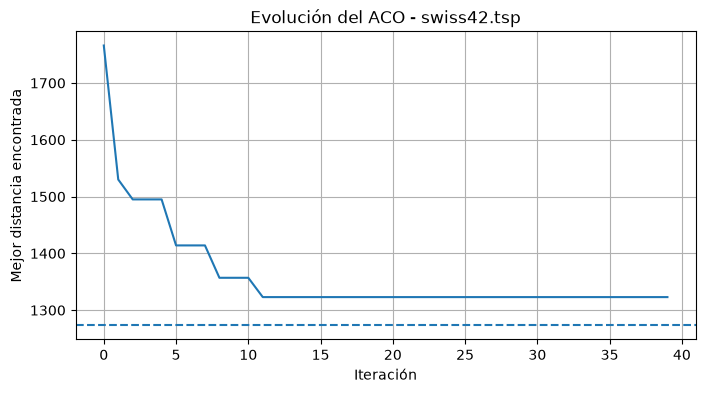

In [15]:
#Evolución de la mejor distancia encontrada a lo largo de las iteraciones de ACO
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(historico_aco)
plt.axhline(y=1273, linestyle="--")
plt.title("Evolución del ACO - swiss42.tsp")
plt.xlabel("Iteración")
plt.ylabel("Mejor distancia encontrada")
plt.grid(True)
plt.show()

## 7.1 Comparativa final (incluyendo ACO)

In [16]:
print("Mejor solución conocida (swiss42.tsp)               :", 1273)
print("-"*70)
print("Búsqueda aleatoria                                    :", dist_aleatoria)
print("Búsqueda local (2-opt)                                :", dist_local)
print("Búsqueda local con entornos variables (VNS) [MEJORA]   :", dist_vns)
print("Recocido simulado (SA)                                :", dist_sa)
print("Recocido simulado con vecino menos aleatorio [MEJORA]  :", dist_sa_mejorado)
print("Colonia de hormigas (ACO)                              :", dist_aco)

Mejor solución conocida (swiss42.tsp)               : 1273
----------------------------------------------------------------------
Búsqueda aleatoria                                    : 3698
Búsqueda local (2-opt)                                : 1643
Búsqueda local con entornos variables (VNS) [MEJORA]   : 1671
Recocido simulado (SA)                                : 1804
Recocido simulado con vecino menos aleatorio [MEJORA]  : 1445
Colonia de hormigas (ACO)                              : 1323
